In [313]:
from ase import Atoms
from xtb.ase.calculator import XTB
# Import read from ase 
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt

# DScribe Testing

The goal of this package is to use the DScribe library and compare the various descriptors it provides for a set of molecules. Goal is to test the seperability and clustering performance of this different descriptors. What we first to is to import some different local minima of the water dimer and calculate the energy, then the descriptors

/tmp/ipykernel_1427904/1041920306.py:10: FutureWarning: Please use atoms.calc = calc
  mol.set_calculator(XTB(method="GFN2-xTB"))


Energies of the water dimer minima:
Minimum 1: -276.1592 eV
Minimum 2: -276.0834 eV
Minimum 3: -276.1137 eV
Minimum 4: -276.0856 eV


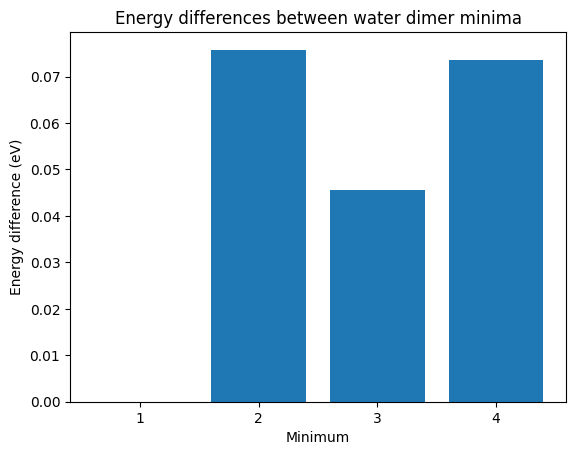

In [314]:
h2o_dimer_min1_path = "/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_globalmin.xyz"
h2o_dimer_min2_path = "/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_local1.xyz"
h2o_dimer_min3_path = "/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2_local3.xyz"
h2o_dimer_min4_path = "/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/water_dimer_local_minima/h2o_2local2.xyz"

molecule_paths = [h2o_dimer_min1_path, h2o_dimer_min2_path, h2o_dimer_min3_path, h2o_dimer_min4_path]
molecules = [read(path) for path in molecule_paths]
energies = []
for mol in molecules:
    mol.set_calculator(XTB(method="GFN2-xTB"))
    energy = mol.get_potential_energy()
    energies.append(energy)
print("Energies of the water dimer minima:")
for i, energy in enumerate(energies):
    print(f"Minimum {i+1}: {energy:.4f} eV")

species = set()
for mol in molecules:
    species.update(mol.get_chemical_symbols())

# Plot the difference in energy between the minima
energy_differences = [energy - energies[0] for energy in energies]
plt.bar(range(1, len(energy_differences) + 1), energy_differences)
plt.xlabel("Minimum")
plt.ylabel("Energy difference (eV)")
plt.title("Energy differences between water dimer minima")
plt.xticks(range(1, len(energy_differences) + 1))
plt.show()  




### Compute Descriptors and Analyze Feature Space using UMAP

We now analyze what happens if we compute first the local descriptors SOAP

In [315]:
from dscribe.descriptors import SOAP

r_cut = 10
n_max = 12
l_max = 8
sigma = 0.5 


soap = SOAP(
    species = list(species),
    r_cut = r_cut,
    n_max = n_max,
    l_max = l_max,
    average="outer"
)

soap_descriptors = soap.create(molecules)
print("SOAP descriptors shape:", soap_descriptors.shape)


SOAP descriptors shape: (4, 2700)


/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


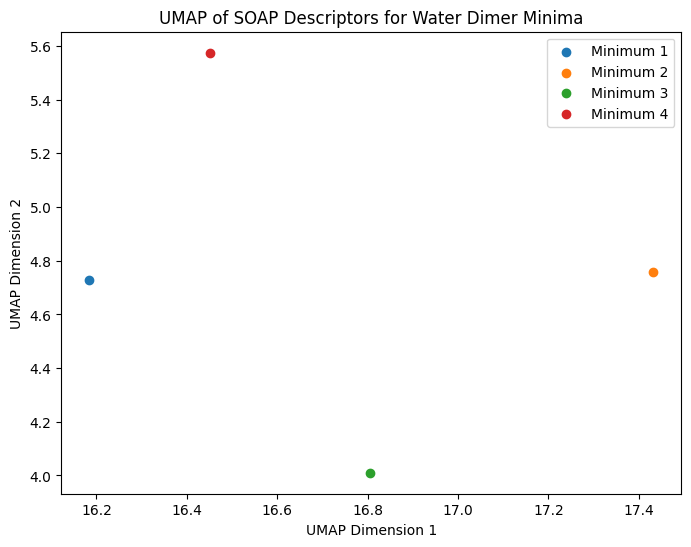

In [316]:
from umap import UMAP

# Reduce dimensionality with UMAP
umap = UMAP(n_components=2, random_state=42)
soap_umap = umap.fit_transform(soap_descriptors)

# Plot UMAP results
plt.figure(figsize=(8, 6))
for i in range(len(molecules)):
    plt.scatter(soap_umap[i, 0], soap_umap[i, 1], label=f"Minimum {i+1}")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP of SOAP Descriptors for Water Dimer Minima")
plt.legend()
plt.show()

This plot clearly shows that with SOAP we are clearly able to correctly distinguish between the different local minima in the structure space. These are in this representation well separated which means that also clustering should be possible.

Next we consider the MBTR descriptor. This is a global descriptor where the order $k$ tells us how many body interactions are considered. we will consider $k=2$ and $k=3$ which are distances and angles respectively.

In [317]:
# Setup k=2 MBTR
from dscribe.descriptors import MBTR

mbtr_k2 = MBTR(
    species = list(species),
    geometry={"function": "distance"},
    grid={"min": 0, "max": 10, "n": 200, "sigma": 0.1},
    weighting={"function": "exp", "scale": 0.5, 'threshold': 1e-3},
    normalization="l2"
)
mbtr_k2_descriptors = mbtr_k2.create(molecules)
print("MBTR k=2 descriptors shape:", mbtr_k2_descriptors.shape)

mtbr_k3 = MBTR(
    species = list(species),
    geometry={"function": "angle"},
    grid={"min": 0, "max": 180, "n": 200, "sigma": 0.1},
    weighting={"function": "exp", "scale": 0.5, 'threshold': 1e-3},
    normalization="l2"
)
mbtr_k3_descriptors = mtbr_k3.create(molecules)
print("MBTR k=3 descriptors shape:", mbtr_k3_descriptors.shape)

MBTR k=2 descriptors shape: (4, 600)
MBTR k=3 descriptors shape: (4, 1200)


/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),


/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


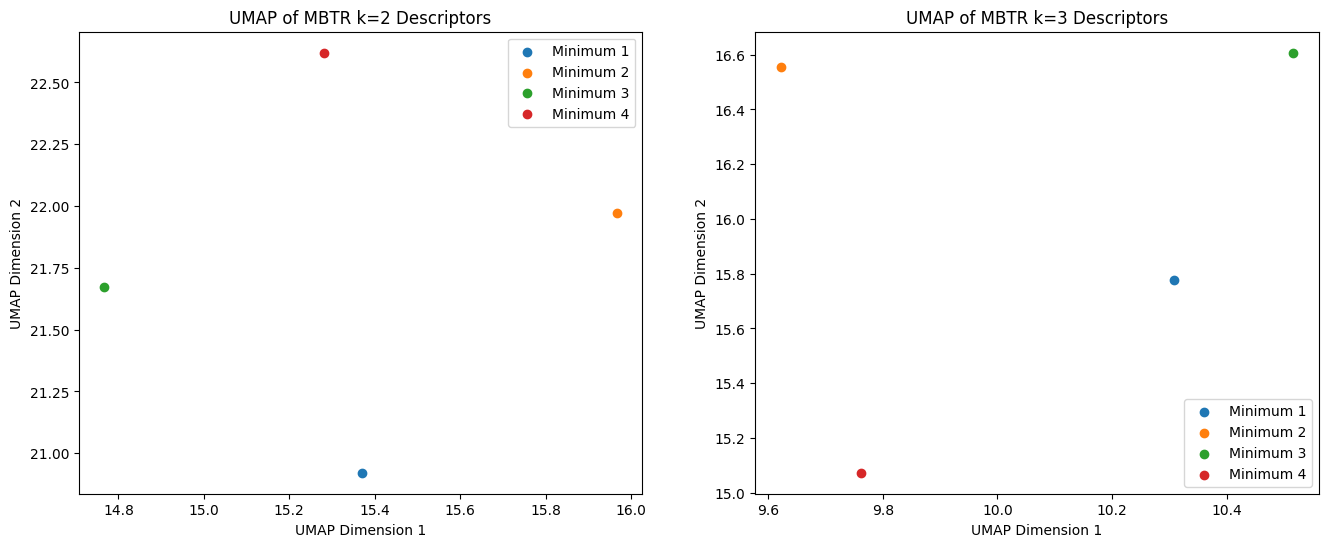

In [318]:
# Plot Side by side UMAP for MBTR k=2 and k=3
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# UMAP for MBTR k=2
umap_k2 = UMAP(n_components=2, random_state=42)
mbtr_k2_umap = umap_k2.fit_transform(mbtr_k2_descriptors)
for i in range(len(molecules)):
    axes[0].scatter(mbtr_k2_umap[i, 0], mbtr_k2_umap[i, 1], label=f"Minimum {i+1}")
axes[0].set_xlabel("UMAP Dimension 1")
axes[0].set_ylabel("UMAP Dimension 2")
axes[0].set_title("UMAP of MBTR k=2 Descriptors")
axes[0].legend()

# UMAP for MBTR k=3
umap_k3 = UMAP(n_components=2, random_state=42)
mbtr_k3_umap = umap_k3.fit_transform(mbtr_k3_descriptors)
for i in range(len(molecules)):
    axes[1].scatter(mbtr_k3_umap[i, 0], mbtr_k3_umap[i, 1], label=f"Minimum {i+1}")
axes[1].set_xlabel("UMAP Dimension 1")
axes[1].set_ylabel("UMAP Dimension 2")
axes[1].set_title("UMAP of MBTR k=3 Descriptors")
axes[1].legend()
plt.show()

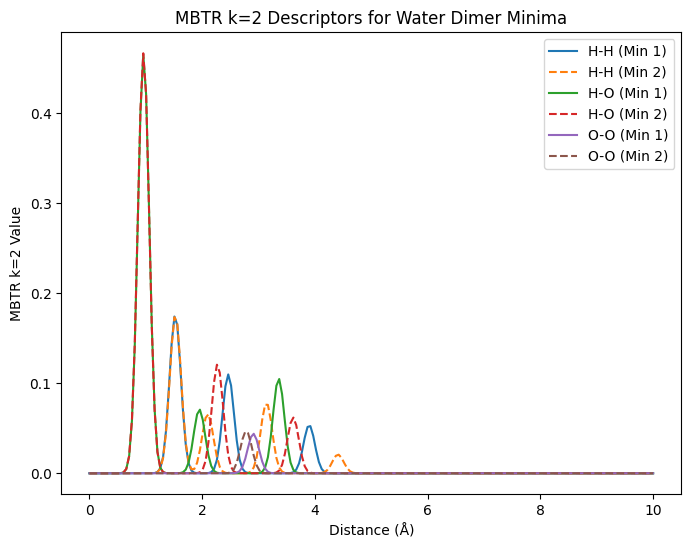

In [319]:
# Visualization for k=2
n_elements = len(species)
x = np.linspace(0, 10, 200)

fig, ax = plt.subplots(figsize=(8, 6))
molecule1 = molecules[0]
molecule2 = molecules[1]
molecule3 = molecules[2]
molecule4 = molecules[3]

for i in range(n_elements):
    for j in range(n_elements):
        if j >= i:
            i_species = mbtr_k2.species[i]
            j_species = mbtr_k2.species[j]
            loc = mbtr_k2.get_location((i_species, j_species))
            ax.plot(x, mbtr_k2_descriptors[0, loc], label=f"{i_species}-{j_species} (Min 1)")
            ax.plot(x, mbtr_k2_descriptors[1, loc], label=f"{i_species}-{j_species} (Min 2)", linestyle='dashed')
            #ax.plot(x, mbtr_k2_descriptors[2, loc], label=f"{i_species}-{j_species} (Min 3)", linestyle='dotted')
            #ax.plot(x, mbtr_k2_descriptors[3, loc], label=f"{i_species}-{j_species} (Min 4)", linestyle='dashdot')
ax.set_xlabel("Distance (Å)")
ax.set_ylabel("MBTR k=2 Value")
ax.set_title("MBTR k=2 Descriptors for Water Dimer Minima")
ax.legend()
plt.show()


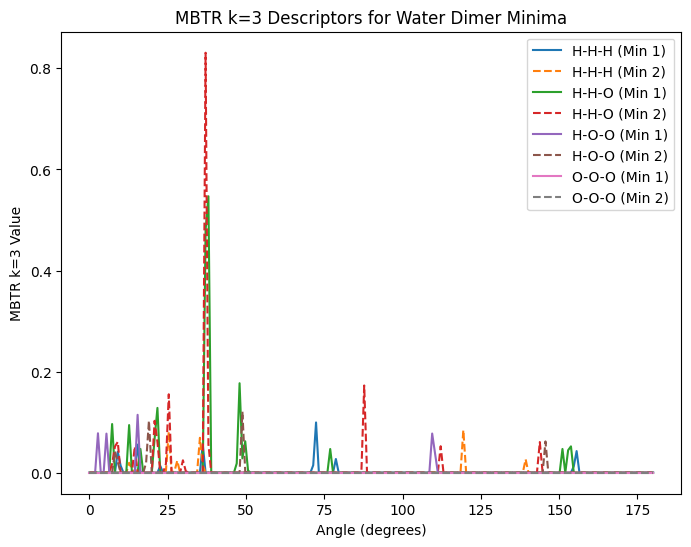

In [320]:
# Plot the respective visualization for k=3
x = np.linspace(0, 180, 200)
fig, ax = plt.subplots(figsize=(8, 6))
for i in range(n_elements):
    for j in range(n_elements):
        for k in range(n_elements):
            if k >= j >= i:
                i_species = mtbr_k3.species[i]
                j_species = mtbr_k3.species[j]
                k_species = mtbr_k3.species[k]
                loc = mtbr_k3.get_location((i_species, j_species, k_species))
                ax.plot(x, mbtr_k3_descriptors[0, loc], label=f"{i_species}-{j_species}-{k_species} (Min 1)")
                ax.plot(x, mbtr_k3_descriptors[1, loc], label=f"{i_species}-{j_species}-{k_species} (Min 2)", linestyle='dashed')
ax.set_xlabel("Angle (degrees)")
ax.set_ylabel("MBTR k=3 Value")
ax.set_title("MBTR k=3 Descriptors for Water Dimer Minima")
ax.legend()
plt.show()

Generated 50 perturbed structures for Minimum 1
SOAP descriptors shape for perturbed structures: (50, 2700)


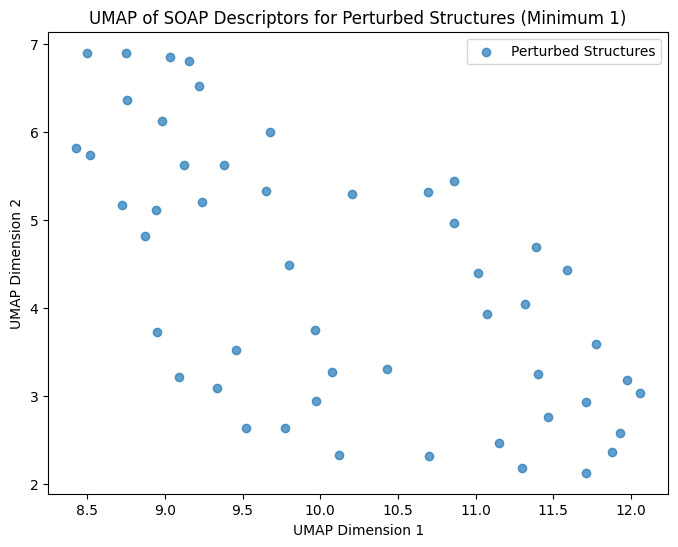

In [321]:
def generate_perturbed_structures(molecule, n_perturbations=50, max_displacement=0.1):
    perturbed_structures = []
    for _ in range(n_perturbations):
        perturbed = molecule.copy()
        displacements = np.random.uniform(-max_displacement, max_displacement, size=perturbed.get_positions().shape)
        perturbed.set_positions(perturbed.get_positions() + displacements)
        perturbed_structures.append(perturbed)
    return perturbed_structures

# Generate perturbed structures for the first minimum
perturbed_structures = generate_perturbed_structures(molecules[0], n_perturbations=50, max_displacement=0.1)
print(f"Generated {len(perturbed_structures)} perturbed structures for Minimum 1")

# Compute SOAP descriptors for perturbed structures
perturbed_soap_descriptors = soap.create(perturbed_structures)
print("SOAP descriptors shape for perturbed structures:", perturbed_soap_descriptors.shape)

# Reduce dimensionality with UMAP for perturbed structures
perturbed_soap_umap = umap.fit_transform(perturbed_soap_descriptors)

# Plot UMAP results for perturbed structures
plt.figure(figsize=(8, 6))
plt.scatter(perturbed_soap_umap[:, 0], perturbed_soap_umap[:, 1], label="Perturbed Structures", alpha=0.7)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP of SOAP Descriptors for Perturbed Structures (Minimum 1)")
plt.legend()
plt.show()

SOAP descriptors shape for all perturbed structures: (200, 2700)


/tmp/ipykernel_1427904/3575291949.py:14: FutureWarning: Please use atoms.calc = calc
  perturbed.set_calculator(XTB(method="GFN2-xTB"))


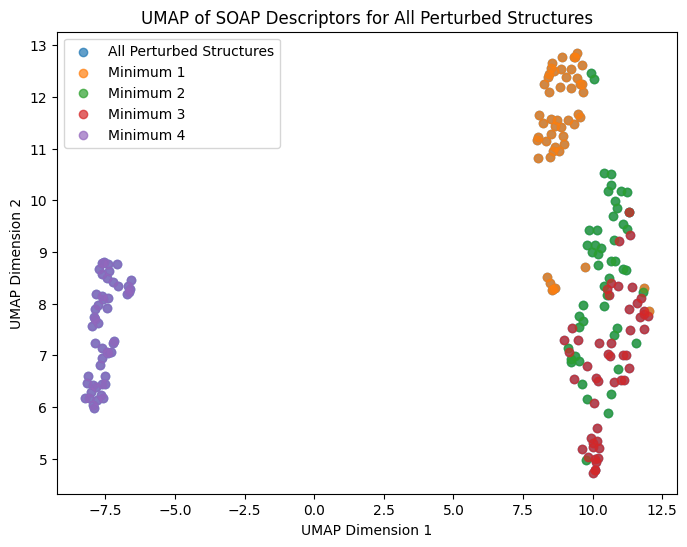

In [322]:
# Generate perturbed structures for all minima and compute SOAP descriptors
all_perturbed_structures = []
true_labels = []
for mol in molecules:
    perturbed_structures = generate_perturbed_structures(mol, n_perturbations=50, max_displacement=0.1)
    all_perturbed_structures.extend(perturbed_structures)
    true_labels.extend([f"Minimum {i+1}" for i in range(len(perturbed_structures))])
all_perturbed_soap_descriptors = soap.create(all_perturbed_structures)
print("SOAP descriptors shape for all perturbed structures:", all_perturbed_soap_descriptors.shape)

# compute energy of all perturbed structures
all_perturbed_energies = []
for perturbed in all_perturbed_structures:
    perturbed.set_calculator(XTB(method="GFN2-xTB"))
    energy = perturbed.get_potential_energy()
    all_perturbed_energies.append(energy)

# add energies to feature_matrix
all_perturbed_features = np.hstack((all_perturbed_soap_descriptors, np.array(all_perturbed_energies).reshape(-1, 1)))
# normalize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
all_perturbed_features_scaled = scaler.fit_transform(all_perturbed_features)

# Reduce dimensionality with UMAP for all perturbed structures
all_perturbed_soap_umap = umap.fit_transform(all_perturbed_soap_descriptors)
# Plot UMAP results for all perturbed structures
plt.figure(figsize=(8, 6))
plt.scatter(all_perturbed_soap_umap[:, 0], all_perturbed_soap_umap[:, 1], label="All Perturbed Structures", alpha=0.7)
# color the points acoording to their true labels
for i in range(len(molecules)):
    plt.scatter(all_perturbed_soap_umap[i*50:(i+1)*50, 0], all_perturbed_soap_umap[i*50:(i+1)*50, 1], label=f"Minimum {i+1}", alpha=0.7)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP of SOAP Descriptors for All Perturbed Structures")
plt.legend()
plt.show()

/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


Combined MBTR k=1, k=2, k=3 descriptors shape: (4, 2000)


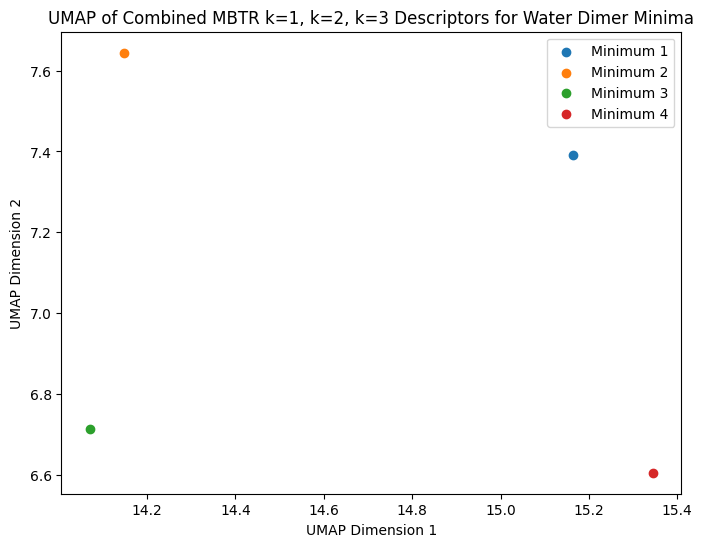

In [323]:
# Generate a Feature matrix with k=1,k=2 and k=3 together normalized and plot the UMAP for that
mbtr_k1 = MBTR(
    species = list(species),
    geometry={"function": "atomic_number"},
    grid={"min": 0, "max": 100, "n": 100, "sigma": 0.1},
    normalization="l2"
)
mbtr_k1_descriptors = mbtr_k1.create(molecules)
mbtr_k2_descriptors = mbtr_k2.create(molecules)
mbtr_k3_descriptors = mtbr_k3.create(molecules)
mbtr_k1_k2_k3_descriptors = np.hstack((mbtr_k1_descriptors, mbtr_k2_descriptors, mbtr_k3_descriptors))
print("Combined MBTR k=1, k=2, k=3 descriptors shape:", mbtr_k1_k2_k3_descriptors.shape)
mbtr_k1_k2_k3_descriptors /= np.linalg.norm(mbtr_k1_k2_k3_descriptors, axis=1, keepdims=True)

umap_k123 = UMAP(n_components=2, random_state=42)
mbtr_k123_umap = umap_k123.fit_transform(mbtr_k1_k2_k3_descriptors)
plt.figure(figsize=(8, 6))
for i in range(len(molecules)):
    plt.scatter(mbtr_k123_umap[i, 0], mbtr_k123_umap[i, 1], label=f"Minimum {i+1}")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP of Combined MBTR k=1, k=2, k=3 Descriptors for Water Dimer Minima")
plt.legend()
plt.show()

/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),


Combined MBTR k=1, k=2, k=3 descriptors shape for perturbed structures: (200, 2000)


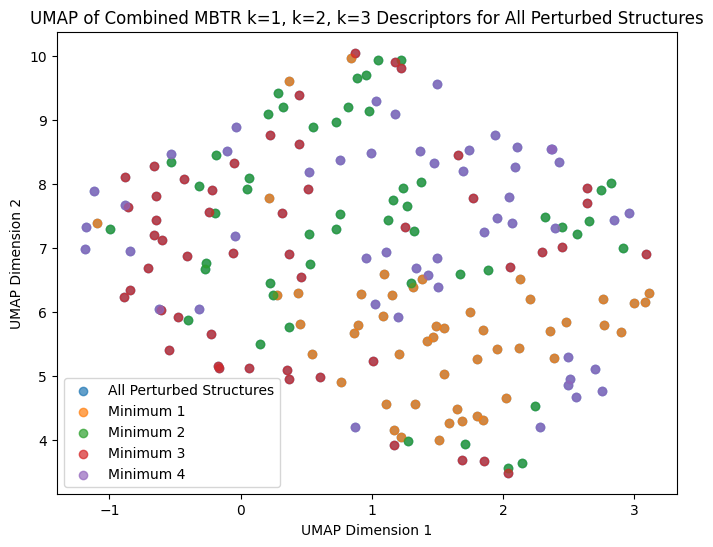

In [324]:
# Test this for the perturbed structures as well
all_perturbed_mbtr_k1_descriptors = mbtr_k1.create(all_perturbed_structures)
all_perturbed_mbtr_k2_descriptors = mbtr_k2.create(all_perturbed_structures)
all_perturbed_mbtr_k3_descriptors = mtbr_k3.create(all_perturbed_structures)
all_perturbed_mbtr_k1_k2_k3_descriptors = np.hstack((all_perturbed_mbtr_k1_descriptors, all_perturbed_mbtr_k2_descriptors, all_perturbed_mbtr_k3_descriptors))
print("Combined MBTR k=1, k=2, k=3 descriptors shape for perturbed structures:", all_perturbed_mbtr_k1_k2_k3_descriptors.shape)

all_perturbed_mbtr_k123_umap = umap_k123.fit_transform(all_perturbed_mbtr_k1_k2_k3_descriptors)
plt.figure(figsize=(8, 6))
plt.scatter(all_perturbed_mbtr_k123_umap[:, 0], all_perturbed_mbtr_k123_umap[:, 1], label="All Perturbed Structures", alpha=0.7)
# plot true labels for the minima
for i in range(len(molecules)):
    plt.scatter(all_perturbed_mbtr_k123_umap[i*50:(i+1)*50, 0], all_perturbed_mbtr_k123_umap[i*50:(i+1)*50, 1], label=f"Minimum {i+1}", alpha=0.7)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP of Combined MBTR k=1, k=2, k=3 Descriptors for All Perturbed Structures")
plt.legend()
plt.show()